Ridge loss: 5063.630801267637
Ridge loss: 0.9651703035259777
Ridge loss: 0.96098296279686
Ridge loss: 0.9609508587490688
Ridge loss: 0.9609503222632416
Ridge loss: 0.9609502923667916
Ridge loss: 0.9609502900084624
Ridge loss: 0.960950289815561
Ridge loss: 0.9609502897997365
Ridge loss: 0.9609502897984356


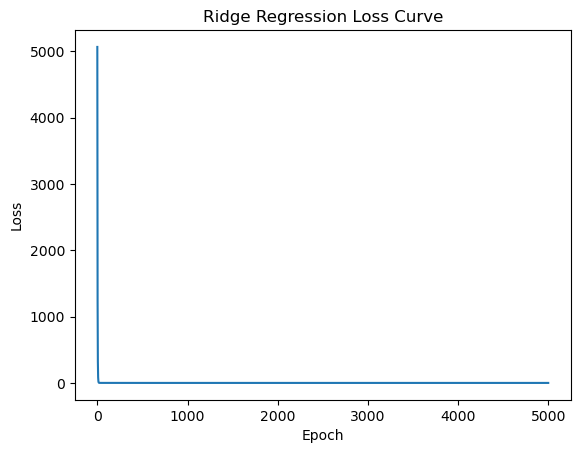


Manual GD parameters and evaluation metrics:
w: [ 3.33949241  0.46856835 11.13104736]
b: 68.75728620613215
MSE: 0.9609502897983309
Train R2 0.9974806006034453
Test R2: 0.9950713147399917

sklearn parameters and evaluation metrics:
w: [ 3.33949241  0.46856835 11.13104736]
b: [68.75728621]
MSE= 0.6227703368324307
Train R2= 0.9974806006034531
Test R2= 0.9950713147399745

comparison of Ridge Regression manually and sklearn in tabular form 


,Model,Weights (w),Bias (b),Loss,Train R2,Test R2
0,Manual GD,"[3.3395, 0.4686, 11.131]",68.7573,0.9610,0.9975,0.9951
1,Sklearn,"[3.3395, 0.4686, 11.131]",[68.7573],0.6228,0.9975,0.9951


In [168]:

#importing-libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#loading-the-dataset
df=pd.read_csv(r"C:\Users\USER\Downloads\student_scores.csv")
df.head()

#data-preprocessing
x=df.iloc[:,:-1].to_numpy()
#feature-normalization
mean=np.mean(x,axis=0)
std=np.std(x,axis=0)
x_norm=(x-mean)/std
X=x_norm
y=df.iloc[:,-1].to_numpy().reshape(-1,1)

#train-test-split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#manual-implementation-using-gradient-descent
#model-initialization
n=len(y_train)
w=np.zeros((X.shape[1],1))
b=0
alpha=0.1
epoch=5000
lambda_=0.1  #regularization strength
loss_history=[]


for i in range(epoch):
 #model-initialization
 y_pred_train=x_train.dot(w)+b
    
 #gradient-computation
 dw=(-2/n)*x_train.T.dot(y_train-y_pred_train)+(2*lambda_/n)*w
 db=(-2/n)*np.sum(y_train-y_pred_train)
 
 #parameter-updates
 w=w-alpha*dw
 b=b-alpha*db
    
#loss-function-and-convergence
 MSE = np.mean((y_train - y_pred_train)**2)
#ridge loss
 ridge_loss=MSE+(lambda_/n)*np.sum(w**2)

 #use to plot loss graph
 loss_history.append(ridge_loss)

#print loss
 if i%500==0:
    print("Ridge loss:",ridge_loss)
     
#model-evaluation
#r2 on train data
y_pred_train=x_train.dot(w)+b
s_res=np.sum((y_train-y_pred_train)**2)
s_tot=np.sum((y_train-np.mean(y_train))**2)
r2_train=1-(s_res/s_tot)


#r2 on test data
y_test_pred = x_test.dot(w) + b
ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_test = 1 - (ss_res/ss_tot)

#loss-curve-visualization
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ridge Regression Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

#manual-GD-parameters-and-evaluation-metrics
print()
print("Manual GD parameters and evaluation metrics:")
print("w:", w.ravel())
print("b:", b)
print("MSE:", ridge_loss)
print("Train R2",r2_train)
print("Test R2:", r2_test)

#comparison-with-sklearn-ridge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
model=Ridge(alpha=0.1)
model.fit(x_train,y_train)
w_s=model.coef_
b_s=model.intercept_
y_pred_train=model.predict(x_train)
MSE=mean_squared_error(y_train,y_pred_train)

#sklearn-parameters-and-evaluation-metrics
print()
print("sklearn parameters and evaluation metrics:")
print("w:",w_s)
print("b:",b_s)
print("MSE=",MSE)
Train_R2=model.score(x_train,y_train)
print("Train R2=",Train_R2)
Test_R2=model.score(x_test,y_test)
print("Test R2=",Test_R2)

#GD to compare`
w_manual=w.ravel()
b_manual=b
loss_manual=ridge_loss
Train_R2_manual=r2_train
Test_R2_manual=r2_test

#sklearn to compare
w_sk=w_s.ravel()
b_sk=b_s.ravel()
loss_sk=MSE
Train_R2_sk=Train_R2
Test_R2_sk=Test_R2

#compare-manual-GD-and-sklearn
compare = pd.DataFrame({
    "Model": ["Manual GD", "Sklearn"],
    "Weights (w)": [np.round(w_manual,4), np.round(w_sk,4)],
    "Bias (b)": [np.round(b_manual,4), np.round(b_sk,4)],
    "Loss": [round(loss_manual,4), round(loss_sk,4)],
    "Train R2": [round(Train_R2_manual,4), round(Train_R2_sk,4)],
    "Test R2": [round(Test_R2_manual,4), round(Test_R2_sk,4)]
})
print()
print("comparison of Ridge Regression manually and sklearn in tabular form ")
compare